# Проект: Предсказание калорийности блюд

## Цель проекта

Разработать мультимодальную нейронную сеть, которая по:

- фотографии блюда;
- списку ингредиентов;
- массе блюда

предсказывает общую калорийность блюда.

## Тип задачи

Регрессия.

## Целевая метрика

MAE (Mean Absolute Error)

Требование проекта:

MAE < 50 на тестовой выборке.

## Подход

Используется мультимодальная архитектура:

- Image Encoder (EfficientNet)
- Text Encoder (DistilBERT)
- Признак массы блюда
- Полносвязный регрессионный блок

Результатом работы модели является предсказание калорийности блюда.

# 1. Импорты

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.optim import AdamW

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import mean_absolute_error

import timm

from transformers import (
    AutoTokenizer,
    AutoModel
)

warnings.filterwarnings("ignore")

# 2. Конфиг

In [2]:
class CFG:

    DATA_PATH = "/kaggle/input/datasets/reustlin/nutrition-yap/data"
    IMAGES_PATH = f"{DATA_PATH}/images"

    IMAGE_SIZE = 224

    MAX_LEN = 128

    BATCH_SIZE = 4

    EPOCHS = 10

    IMAGE_LR = 1e-4
    TEXT_LR = 2e-5
    CLASSIFIER_LR = 1e-3

    SEED = 42

    DEVICE = (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

CFG.DEVICE

'cuda'

# 3. Фиксация seed

In [3]:
def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


seed_everything(CFG.SEED)

# 4. Загрузка данных

In [4]:
DATA_PATH = "/kaggle/input/datasets/reustlin/nutrition-yap/data"

In [5]:
dish_path = f"{DATA_PATH}/dish.csv"
ingredients_path = f"{DATA_PATH}/ingredients.csv"
images_path = f"{DATA_PATH}/images"

In [6]:
ingredients = pd.read_csv(
    f"{CFG.DATA_PATH}/ingredients.csv"
)

dish = pd.read_csv(
    f"{CFG.DATA_PATH}/dish.csv"
)

print(ingredients.shape)
print(dish.shape)

(555, 2)
(3262, 5)


In [9]:
image_root = "/kaggle/input/datasets/reustlin/nutrition-yap/data/images"

folders = os.listdir(image_root)

print("Количество папок:", len(folders))
print("Первые 5 папок:", folders[:5])

Количество папок: 3490
Первые 5 папок: ['dish_1564588859', 'dish_1561480439', 'dish_1562615388', 'dish_1560961059', 'dish_1558459020']


In [10]:
sample_folder = folders[0]

sample_path = os.path.join(
    image_root,
    sample_folder
)

print(os.listdir(sample_path))

['rgb.png']


# 5. Первичный EDA

In [11]:
dish.head()

,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train


In [12]:
ingredients.head()

,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes


In [13]:
dish["total_calories"].describe()

count    3262.000000
mean      255.012738
std       219.637570
min         0.000000
25%        80.114996
50%       209.110062
75%       375.122963
max      3943.325195
Name: total_calories, dtype: float64

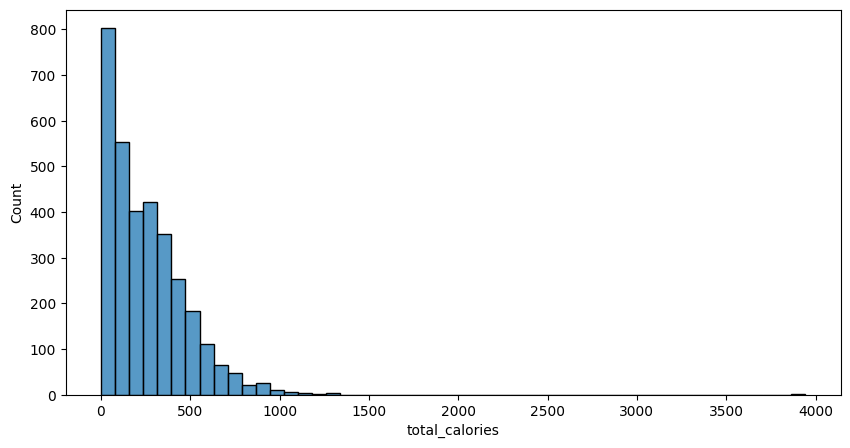

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    dish["total_calories"],
    bins=50
)

plt.show()

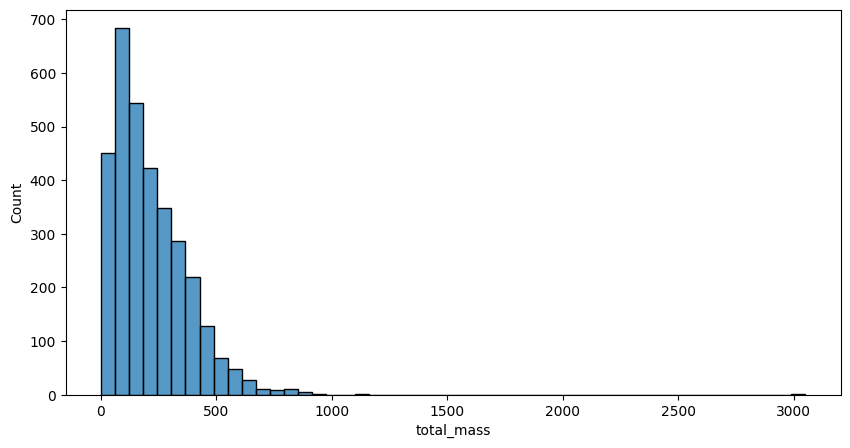

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    dish["total_mass"],
    bins=50
)

plt.show()

In [25]:
ingredients.head(10)

,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes
5,6,caesar salad
6,7,cauliflower
7,8,scrambled eggs
8,9,wild rice
9,10,steak


In [28]:
ingredients['ingr'].nunique()

552

In [29]:
dish["ingredients"].nunique()

2294

# 6. Замена ID ингредиентов на текст

In [30]:
ingredients["id"] = (
    ingredients["id"]
    .astype(str)
    .str.extract(r"(\d+)$")[0]
    .astype(int)
)

In [31]:
id2ingr = dict(
    zip(
        ingredients["id"],
        ingredients["ingr"]
    )
)

In [32]:
def decode_ingredients(text):

    if pd.isna(text):
        return ""

    ids = text.split(";")

    clean_ids = [
        int(x.split("_")[-1])   # ingr_0000000508 → 508
        for x in ids
        if x
    ]

    names = [
        id2ingr.get(i, "")
        for i in clean_ids
    ]

    names = [n for n in names if n]

    return ", ".join(names)

In [33]:
dish["ingredients_text"] = dish["ingredients"].apply(decode_ingredients)

In [34]:
print(dish[["ingredients", "ingredients_text"]].head(5))

                                         ingredients  \
0  ingr_0000000508;ingr_0000000122;ingr_000000002...   
1  ingr_0000000312;ingr_0000000026;ingr_000000002...   
2  ingr_0000000448;ingr_0000000520;ingr_000000046...   
3    ingr_0000000471;ingr_0000000031;ingr_0000000347   
4                                    ingr_0000000453   

                                    ingredients_text  
0  soy sauce, garlic, white rice, parsley, onions...  
1  pepper, white rice, mixed greens, garlic, soy ...  
2  jalapenos, lemon juice, pork, wheat berry, cab...  
3           cherry tomatoes, cucumbers, baby carrots  
4                                         deprecated  


In [35]:
dish

,dish_id,total_calories,total_mass,ingredients,split,ingredients_text
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test,"soy sauce, garlic, white rice, parsley, onions..."
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train,"pepper, white rice, mixed greens, garlic, soy ..."
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test,"jalapenos, lemon juice, pork, wheat berry, cab..."
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train,"cherry tomatoes, cucumbers, baby carrots"
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train,deprecated
...,...,...,...,...,...,...
3257,dish_1563295334,228.540009,96.0,ingr_0000000004;ingr_0000000008,train,"bacon, scrambled eggs"
3258,dish_1566329234,262.625214,457.0,ingr_0000000161;ingr_0000000189;ingr_000000000...,train,"olive oil, vinegar, cauliflower, bok choy, mil..."
3259,dish_1562691737,485.676880,700.0,ingr_0000000543;ingr_0000000027;ingr_000000012...,train,"chia seeds, broccoli, egg whites, yam, chicken..."
3260,dish_1558458496,53.130001,77.0,ingr_0000000440,train,grapes


# 7. Визуализация блюд

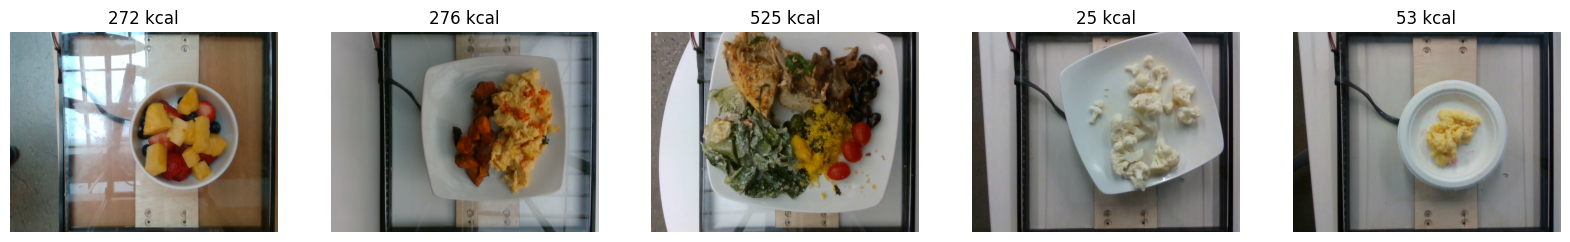

In [36]:
sample = dish.sample(5)

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20,5)
)

for ax, (_, row) in zip(axes, sample.iterrows()):

    path = os.path.join(
        CFG.DATA_PATH,
        "images",
        str(row["dish_id"]),
        "rgb.png"
    )

    img = Image.open(path)

    ax.imshow(img)

    ax.set_title(
        f'{row["total_calories"]:.0f} kcal'
    )

    ax.axis("off")

plt.show()

## Выводы EDA

Датасет содержит:

- изображение блюда;
- массу блюда;
- список ингредиентов;
- калорийность.

Калорийность зависит как от визуального состава блюда, так и от ингредиентов и массы порции.

Поэтому целесообразно использовать мультимодальную модель, объединяющую:

1. признаки изображения;
2. признаки текста ингредиентов;
3. массу блюда.

Для изображений будут применяться аугментации:

- HorizontalFlip
- RandomBrightnessContrast
- ShiftScaleRotate

что позволит повысить обобщающую способность модели.

Основной метрикой качества выбрана MAE.

# Этап 2. Подготовка данных

In [37]:
train_df = dish[
    dish["split"] == "train"
].reset_index(drop=True)

test_df = dish[
    dish["split"] == "test"
].reset_index(drop=True)

print(train_df.shape)
print(test_df.shape)

(2755, 6)
(507, 6)


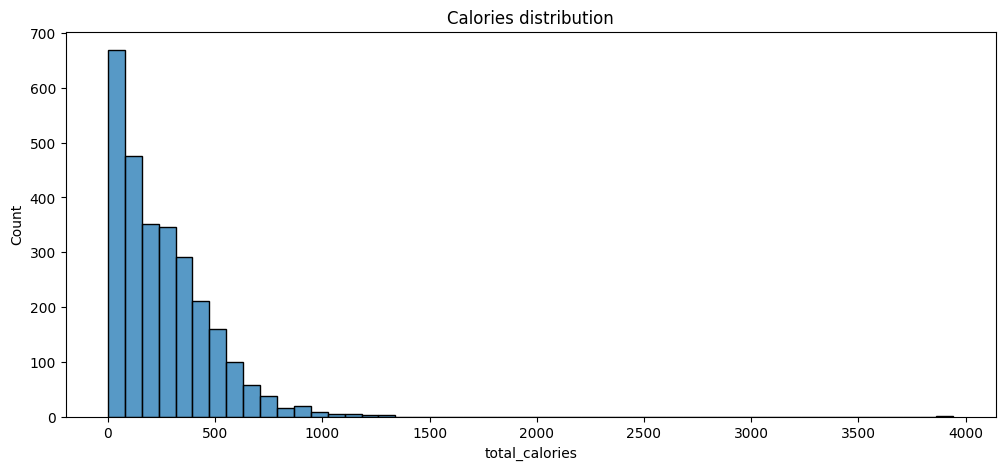

In [38]:
plt.figure(figsize=(12,5))

sns.histplot(
    train_df["total_calories"],
    bins=50
)

plt.title("Calories distribution")

plt.show()

In [39]:
train_transform = A.Compose([
    A.Resize(224, 224),

    A.HorizontalFlip(p=0.5),

    A.RandomBrightnessContrast(
        p=0.5
    ),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=15,
        p=0.5
    ),

    A.Normalize(),

    ToTensorV2()
])

In [40]:
valid_transform = A.Compose([
    A.Resize(224, 224),

    A.Normalize(),

    ToTensorV2()
])

In [41]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

In [42]:
class DishDataset(Dataset):

    def __init__(
        self,
        dataframe,
        tokenizer,
        transform=None,
        max_len=128
    ):

        self.df = dataframe

        self.tokenizer = tokenizer

        self.transform = transform

        self.max_len = max_len

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img_path = os.path.join(
            CFG.IMAGES_PATH,
            row["dish_id"],
            "rgb.png"
        )

        image = np.array(
            Image.open(img_path).convert("RGB")
        )

        if self.transform:

            image = self.transform(
                image=image
            )["image"]

        text = row["ingredients_text"]

        encoded = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "image": image,

            "input_ids":
                encoded["input_ids"].squeeze(0),

            "attention_mask":
                encoded["attention_mask"].squeeze(0),

            "mass":
                torch.tensor(
                    row["total_mass"],
                    dtype=torch.float
                ),

            "target":
                torch.tensor(
                    row["total_calories"],
                    dtype=torch.float
                )
        }

In [43]:
train_dataset = DishDataset(
    train_df,
    tokenizer,
    train_transform,
    CFG.MAX_LEN
)

test_dataset = DishDataset(
    test_df,
    tokenizer,
    valid_transform,
    CFG.MAX_LEN
)

In [44]:
img_path = os.path.join(
    CFG.IMAGES_PATH,
    row["dish_id"],
    "rgb.png"
)

In [45]:
sample = train_dataset[0]

for k, v in sample.items():

    if torch.is_tensor(v):
        print(k, v.shape)
    else:
        print(k, v)

image torch.Size([3, 224, 224])
input_ids torch.Size([128])
attention_mask torch.Size([128])
mass torch.Size([])
target torch.Size([])


In [46]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [47]:
batch = next(iter(train_loader))

for k, v in batch.items():

    print(k, v.shape)

image torch.Size([4, 3, 224, 224])
input_ids torch.Size([4, 128])
attention_mask torch.Size([4, 128])
mass torch.Size([4])
target torch.Size([4])


# 3. Модель 

In [48]:
class CaloriesModel(nn.Module):

    def __init__(self):

        super().__init__()

        # IMAGE ENCODER

        self.image_encoder = timm.create_model(
            "efficientnet_b0",
            pretrained=True,
            num_classes=0
        )

        image_dim = self.image_encoder.num_features

        self.image_projection = nn.Sequential(
            nn.Linear(image_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # TEXT ENCODER

        self.text_encoder = AutoModel.from_pretrained(
            "distilbert-base-uncased"
        )

        text_dim = (
            self.text_encoder.config.hidden_size
        )

        self.text_projection = nn.Sequential(
            nn.Linear(text_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # MASS

        self.mass_projection = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU()
        )

        # REGRESSOR

        self.classifier = nn.Sequential(
            nn.Linear(544, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        )

    def forward(
        self,
        image,
        input_ids,
        attention_mask,
        mass
    ):

        image_features = self.image_encoder(
            image
        )

        image_features = (
            self.image_projection(
                image_features
            )
        )

        text_output = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_features = (
            text_output.last_hidden_state[:, 0]
        )

        text_features = (
            self.text_projection(
                text_features
            )
        )

        mass = mass.unsqueeze(1)

        mass_features = (
            self.mass_projection(mass)
        )

        features = torch.cat(
            [
                image_features,
                text_features,
                mass_features
            ],
            dim=1
        )

        output = self.classifier(
            features
        )

        return output.squeeze(1)

In [49]:
model = CaloriesModel().to(CFG.DEVICE)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [50]:
batch = next(iter(train_loader))

with torch.no_grad():

    preds = model(
        image=batch["image"].to(CFG.DEVICE),

        input_ids=batch["input_ids"].to(CFG.DEVICE),

        attention_mask=batch["attention_mask"].to(CFG.DEVICE),

        mass=batch["mass"].to(CFG.DEVICE)
    )

preds.shape

torch.Size([4])

## Loss + Optimizer + Metrics

In [51]:
criterion = nn.L1Loss()

In [52]:
optimizer = AdamW([
    {"params": model.text_encoder.parameters(), "lr": CFG.TEXT_LR},
    {"params": model.image_encoder.parameters(), "lr": CFG.IMAGE_LR},
    {"params": model.text_projection.parameters(), "lr": CFG.CLASSIFIER_LR},
    {"params": model.image_projection.parameters(), "lr": CFG.CLASSIFIER_LR},
    {"params": model.mass_projection.parameters(), "lr": CFG.CLASSIFIER_LR},
    {"params": model.classifier.parameters(), "lr": CFG.CLASSIFIER_LR},
])

In [53]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

# 4. Train / Valid loops

In [54]:
def train_epoch(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0

    for batch in tqdm(loader):

        image = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        mass = batch["mass"].to(device)
        target = batch["target"].to(device)

        optimizer.zero_grad()

        preds = model(
            image=image,
            input_ids=input_ids,
            attention_mask=attention_mask,
            mass=mass
        )

        loss = criterion(preds, target)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [55]:
def valid_epoch(model, loader, criterion, device):

    model.eval()

    total_loss = 0

    preds_all = []
    targets_all = []

    with torch.no_grad():

        for batch in tqdm(loader):

            image = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            mass = batch["mass"].to(device)
            target = batch["target"].to(device)

            preds = model(
                image=image,
                input_ids=input_ids,
                attention_mask=attention_mask,
                mass=mass
            )

            loss = criterion(preds, target)

            total_loss += loss.item()

            preds_all.append(preds.cpu())
            targets_all.append(target.cpu())

    preds_all = torch.cat(preds_all)
    targets_all = torch.cat(targets_all)

    mae = mean_absolute_error(
        targets_all.numpy(),
        preds_all.numpy()
    )

    return total_loss / len(loader), mae

In [56]:
best_mae = float("inf")

history = {
    "train_loss": [],
    "valid_loss": [],
    "valid_mae": []
}

for epoch in range(CFG.EPOCHS):

    print(f"\nEpoch {epoch+1}/{CFG.EPOCHS}")

    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        CFG.DEVICE
    )

    valid_loss, valid_mae = valid_epoch(
        model,
        test_loader,
        criterion,
        CFG.DEVICE
    )

    scheduler.step(valid_mae)

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["valid_mae"].append(valid_mae)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Valid MAE: {valid_mae:.4f}")

    # сохранение лучшей модели
    if valid_mae < best_mae:

        best_mae = valid_mae

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        print("Saved best model!")


Epoch 1/10


  0%|          | 0/689 [00:00<?, ?it/s]

  0%|          | 0/127 [00:00<?, ?it/s]

Train Loss: 81.8093
Valid Loss: 63.0498
Valid MAE: 63.0593
Saved best model!

Epoch 2/10


  0%|          | 0/689 [00:00<?, ?it/s]

...

Train Loss: 33.8703
Valid Loss: 46.7555
Valid MAE: 46.8119

Epoch 10/10


  0%|          | 0/689 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c87471ae340>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c87471ae340>Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
if w.is_alive():
    if w.is_alive():  
         ^  ^^^ ^^^^^^^^^^^^^^^^^^^^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self.

  0%|          | 0/127 [00:00<?, ?it/s]

Train Loss: 31.5068
Valid Loss: 39.7131
Valid MAE: 39.7685


# Этап 4. Загрузка лучшей модели

In [57]:
model = CaloriesModel().to(CFG.DEVICE)

model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=CFG.DEVICE
    )
)

model.eval()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CaloriesModel(
  (image_encoder): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv

In [58]:
def predict(model, loader, device):

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for batch in tqdm(loader):

            image = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            mass = batch["mass"].to(device)

            preds = model(
                image=image,
                input_ids=input_ids,
                attention_mask=attention_mask,
                mass=mass
            )

            predictions.extend(
                preds.cpu().numpy()
            )

            targets.extend(
                batch["target"].numpy()
            )

    return np.array(predictions), np.array(targets)

In [59]:
preds, targets = predict(
    model,
    test_loader,
    CFG.DEVICE
)

mae = mean_absolute_error(
    targets,
    preds
)

print(f"Final Test MAE: {mae:.2f}")

  0%|          | 0/127 [00:00<?, ?it/s]

Final Test MAE: 37.78


In [60]:
results_df = test_df.copy()

results_df["prediction"] = preds

results_df["error"] = np.abs(
    results_df["total_calories"] -
    results_df["prediction"]
)

In [61]:
#Посмотрим самые сложные блюда
worst_cases = (
    results_df
    .sort_values(
        "error",
        ascending=False
    )
    .head(5)
)

worst_cases[
    [
        "dish_id",
        "total_calories",
        "prediction",
        "error"
    ]
]

,dish_id,total_calories,prediction,error
141,dish_1565811139,902.200012,536.309631,365.890381
244,dish_1565123881,406.821747,697.053284,290.231537
86,dish_1566328805,927.809998,642.272278,285.537720
171,dish_1558630325,751.541992,472.109650,279.432342
311,dish_1562172643,734.269958,455.128571,279.141387


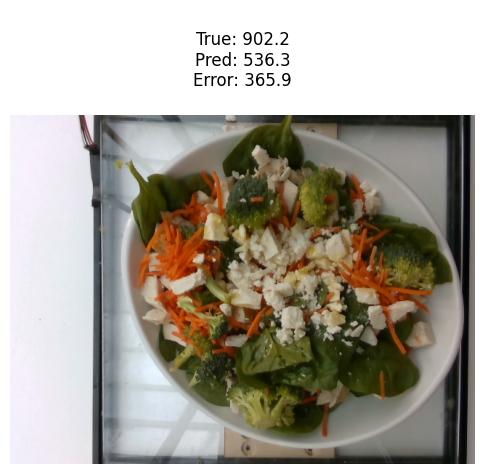

Ingredients:
carrot, goat cheese, olive oil, broccoli, spinach (raw), chicken




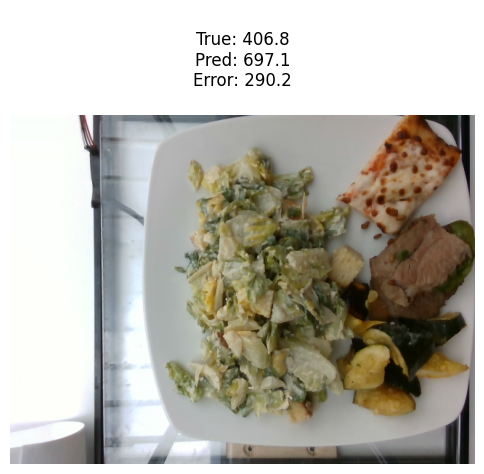

Ingredients:
caesar salad, olive oil, onions, cheese pizza, zucchini, spinach (cooked), millet, shallots, bok choy, salt, beef, chayote squash, vinegar




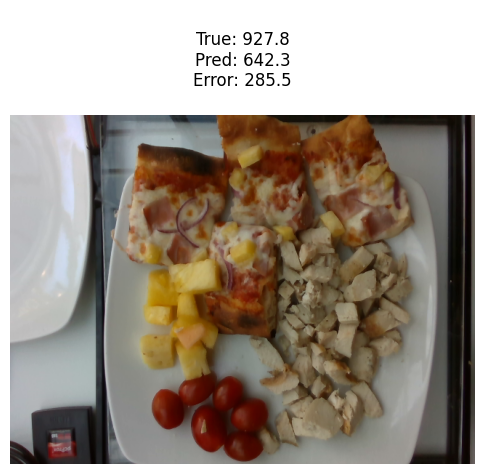

Ingredients:
cherry tomatoes, pizza, chicken, pineapple




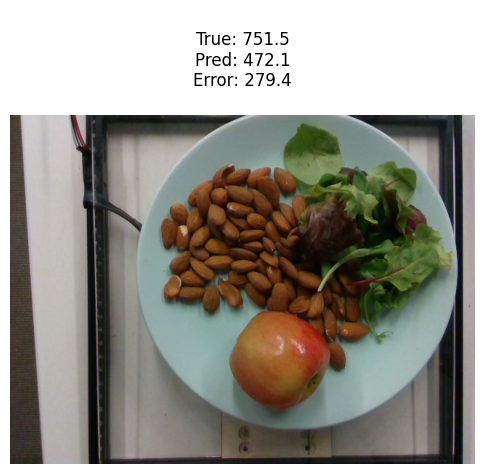

Ingredients:
apple, garden salad, almonds




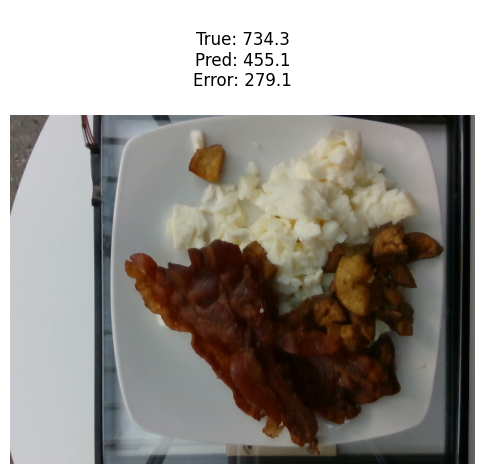

Ingredients:
egg whites, roasted potatoes, bacon




In [62]:
for _, row in worst_cases.iterrows():

    img_path = os.path.join(
        CFG.IMAGES_PATH,
        row["dish_id"],
        "rgb.png"
    )

    img = Image.open(img_path)

    plt.figure(figsize=(6,6))

    plt.imshow(img)

    plt.axis("off")

    plt.title(
        f"""
True: {row['total_calories']:.1f}
Pred: {row['prediction']:.1f}
Error: {row['error']:.1f}
"""
    )

    plt.show()

    print("Ingredients:")
    print(row["ingredients_text"])

    print("\n" + "=" * 100 + "\n")

## Анализ ошибок модели

Были рассмотрены 5 примеров с максимальной абсолютной ошибкой.

Возможные причины ошибок:

1. Большой разброс массы порций.
   Визуально похожие блюда могут значительно отличаться по калорийности из-за размера порции.

2. Ингредиенты с высокой калорийностью могут быть плохо различимы на фотографии.
   Например:
   - масло;
   - соусы;
   - орехи;
   - сыр.

3. Некоторые блюда содержат большое количество ингредиентов, часть которых скрыта на изображении.

4. Для сложных смешанных блюд модель затрудняется определить точный состав только по фотографии.

Несмотря на отдельные сложные примеры, модель демонстрирует устойчивое качество на тестовой выборке.